# **Google Play Store App Success Analysis**

## Problem Statement

Hence Google Play Store is consist of several of thousands application of different categories. Our job is to find the factor leading the app to success, factors could be behalf of Installs, on bhealf of Review & Ratings or behalf of Paid/Unpaid.

## Objective
- Identify factors leading to success
- Compare Unpaid vs Paid Apps
- Analyze impact of size
- User Sentiments

## Approach
- I divided the complete project in 5 different phases (Data Analytic Lifecycle):
  - **Phase 1:** Setup & Import
  - **Phase 2:** Data Cleaning & Transformation
  - **Phase 3:** EDA (Exploratory Data Analysis)
  - **Phase 4:** Visualization
  - **Phase 5:** Insights
- They 3 key phases includes
| Cleaning steps | EDA questions | Visualization |
| :--- | :--- | :--- |
| Fix dtypes (Price, Reviews, Installs) | Category distribution | Bar, box, scatter |
| Drop / impute missing values | Rating by category | Heatmap (correlation) |
| Remove outliers  | Free vs Paid installs | Time series (updates) |
| Drop duplicates | Sentiment analysis | Sentiment stacked bar |


## **Phase 1 :** Setup & Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

In [2]:
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120

In [3]:
PlayStoreData = "Data/Play Store Data.csv"
UserReviews = "Data/User Reviews.csv"

In [4]:
playstore = pd.read_csv(PlayStoreData)
userreviews = pd.read_csv(UserReviews)

## **Phase 2 :** Data Cleaning & Transformation

### Getting info about datasets

In [5]:
playstore.shape

(10841, 13)

In [6]:
userreviews.shape

(64295, 5)

In [7]:
playstore.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [8]:
userreviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  object 
 1   Translated_Review       37427 non-null  object 
 2   Sentiment               37432 non-null  object 
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), object(3)
memory usage: 2.5+ MB


In [9]:
# Snapshot of data in playstore dataset
playstore.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [10]:
# Snapshot of data in userreviews dataset
userreviews.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


### Working with `Installs` feature in **playstore** dataset

In [11]:
playstore['Installs'].value_counts()

Installs
1,000,000+        1579
10,000,000+       1252
100,000+          1169
10,000+           1054
1,000+             907
5,000,000+         752
100+               719
500,000+           539
50,000+            479
5,000+             477
100,000,000+       409
10+                386
500+               330
50,000,000+        289
50+                205
5+                  82
500,000,000+        72
1+                  67
1,000,000,000+      58
0+                  14
0                    1
Free                 1
Name: count, dtype: int64

In [12]:
playstore['Installs'] = playstore['Installs'].str.replace("Free", "0").str.replace('[+,]', "", regex=True).astype(np.int64)

In [13]:
playstore['Installs'].value_counts()

Installs
1000000       1579
10000000      1252
100000        1169
10000         1054
1000           907
5000000        752
100            719
500000         539
50000          479
5000           477
100000000      409
10             386
500            330
50000000       289
50             205
5               82
500000000       72
1               67
1000000000      58
0               16
Name: count, dtype: int64

### Working with `Price` feature in **playstore** dataset

In [14]:
playstore["Price"].value_counts()

Price
0           10040
$0.99         148
$2.99         129
$1.99          73
$4.99          72
            ...  
$394.99         1
$1.26           1
Everyone        1
$1.20           1
$1.04           1
Name: count, Length: 93, dtype: int64

In [15]:
playstore["Price"] = playstore["Price"].str.replace("Everyone", "0").str.replace("$", "").astype(np.float16)

In [16]:
playstore["Price"].value_counts()

Price
0.000000      10041
0.990234        148
2.990234        129
1.990234         73
4.988281         72
              ...  
3.609375          1
395.000000        1
1.259766          1
1.200195          1
1.040039          1
Name: count, Length: 91, dtype: int64

### Working with `Size` feature in **playstore** dataset

In [17]:
playstore["Size"].value_counts().sort_values()

Size
811k                     1
688k                     1
847k                     1
562k                     1
54k                      1
                      ... 
13M                    191
14M                    194
12M                    196
11M                    198
Varies with device    1695
Name: count, Length: 462, dtype: int64

In [18]:
def convertSize(size):
  if 'M' in size:
    return np.float64(size.replace("M", ""))
  elif 'k' in size:
    return np.float64(size.replace('k', ""))/1024
  elif 'G' in size:
    return np.float64(size.replace('G', ""))*1000
  else:
    return np.nan
playstore['Size'] = playstore['Size'].apply(convertSize)

In [19]:
playstore.groupby("Category")["Size"].mean().sort_values(ascending=False)

Category
GAME                   44.370065
FAMILY                 28.319023
TRAVEL_AND_LOCAL       24.654463
SPORTS                 24.338822
HEALTH_AND_FITNESS     22.768851
PARENTING              22.512963
FOOD_AND_DRINK         22.185000
ENTERTAINMENT          21.853333
EDUCATION              20.790600
AUTO_AND_VEHICLES      20.036807
MEDICAL                19.628456
FINANCE                17.928309
SOCIAL                 17.681671
PHOTOGRAPHY            17.367574
DATING                 16.625555
MAPS_AND_NAVIGATION    16.614368
SHOPPING               16.175059
VIDEO_PLAYERS          16.084441
HOUSE_AND_HOME         15.978539
LIFESTYLE              14.754111
BUSINESS               14.471877
EVENTS                 13.963617
BEAUTY                 13.795745
COMICS                 13.484869
BOOKS_AND_REFERENCE    13.310188
WEATHER                13.124006
NEWS_AND_MAGAZINES     13.023615
PRODUCTIVITY           12.980885
ART_AND_DESIGN         12.370968
COMMUNICATION          11.765673
P

In [20]:
categorySizeMean = playstore.groupby('Category')['Size'].mean()

playstore['Size'] = playstore['Size'].fillna(playstore['Category'].map(categorySizeMean))

### Working with `Reviews` feature in **playstore** dataset

In [21]:
def convertReviews(review):
  if 'M' in review:
    return int(float(review.replace('M', ''))) * 1000000
  else:
    return np.int32(review)

playstore['Reviews'] = playstore['Reviews'].apply(convertReviews)

### Working with `Last Updated` feature in **playstore** dataset and aading new column `Year`

In [22]:
playstore['Last Updated'] = pd.to_datetime(playstore['Last Updated'], errors="coerce")

In [23]:
playstore["Year"] = playstore['Last Updated'].dt.year

### Fixing missing `Ratings` in **playstore** dataset

In [24]:
categoryRatingMedian = playstore.groupby('Category')['Rating'].median()

playstore['Rating'] = playstore['Rating'].fillna(playstore['Category'].map(categoryRatingMedian))

In [25]:
playstore["Rating"].value_counts()

Rating
4.3     1979
4.4     1250
4.2     1227
4.5     1154
4.6      823
4.1      747
4.0      568
4.7      499
3.9      386
3.8      303
5.0      274
3.7      239
4.8      234
3.6      174
3.5      163
3.4      128
3.3      102
4.9       87
3.0       83
3.1       69
3.2       64
2.9       45
2.8       42
2.6       25
2.7       25
2.5       21
2.3       20
2.4       19
1.0       16
2.2       14
1.9       13
2.0       12
1.7        8
1.8        8
2.1        8
1.6        4
1.4        3
1.5        3
1.2        1
19.0       1
Name: count, dtype: int64

### Working with *Outliers* and *NaN*

In [26]:
playstore = playstore[playstore['Category'] != '1.9']

In [27]:
playstore = playstore[playstore['Rating'] <= 5.0]

In [28]:
playstore.dropna(subset=['Rating', 'Type', 'Content Rating'], inplace=True)

In [29]:
playstore[['Android Ver', 'Current Ver']] = playstore[['Android Ver', 'Current Ver']].fillna('Unknown')

In [30]:
playstore.isnull().sum()

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
Year              0
dtype: int64

### Removing duplicates

In [31]:
playstore.duplicated().sum()

np.int64(483)

In [32]:
userreviews.duplicated().sum()

np.int64(33616)

In [33]:
playstore = playstore.drop_duplicates()
userreviews = userreviews.drop_duplicates()

### Getting dataset health

In [34]:
playstore.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10356 entries, 0 to 10840
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             10356 non-null  object        
 1   Category        10356 non-null  object        
 2   Rating          10356 non-null  float64       
 3   Reviews         10356 non-null  int64         
 4   Size            10356 non-null  float64       
 5   Installs        10356 non-null  int64         
 6   Type            10356 non-null  object        
 7   Price           10356 non-null  float16       
 8   Content Rating  10356 non-null  object        
 9   Genres          10356 non-null  object        
 10  Last Updated    10356 non-null  datetime64[ns]
 11  Current Ver     10356 non-null  object        
 12  Android Ver     10356 non-null  object        
 13  Year            10356 non-null  float64       
dtypes: datetime64[ns](1), float16(1), float64(3), int64(2), obj

In [35]:
userreviews.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30679 entries, 0 to 64236
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     30679 non-null  object 
 1   Translated_Review       29692 non-null  object 
 2   Sentiment               29697 non-null  object 
 3   Sentiment_Polarity      29697 non-null  float64
 4   Sentiment_Subjectivity  29697 non-null  float64
dtypes: float64(2), object(3)
memory usage: 1.4+ MB


## **Phase 3 :** Exploratory Data Analysis (EDA)

### Basics about playstore and userreviews

In [36]:
playstore.describe()

,Rating,Reviews,Size,Installs,Price,Last Updated,Year
count,10356.000000,1.035600e+04,10356.000000,1.035600e+04,10356.00000,10356,10356.000000
mean,4.203959,4.059438e+05,21.035721,1.415913e+07,1.03125,2017-11-14 08:53:57.079953664,2017.382870
min,1.000000,0.000000e+00,0.008301,0.000000e+00,0.00000,2010-05-21 00:00:00,2010.000000
25%,4.100000,3.200000e+01,5.700000,1.000000e+03,0.00000,2017-09-02 18:00:00,2017.000000
50%,4.300000,1.683000e+03,14.000000,1.000000e+05,0.00000,2018-05-20 00:00:00,2018.000000
75%,4.500000,4.643825e+04,28.000000,1.000000e+06,0.00000,2018-07-19 00:00:00,2018.000000
max,5.000000,7.815831e+07,100.000000,1.000000e+09,400.00000,2018-08-08 00:00:00,2018.000000
std,0.486684,2.696905e+06,21.110851,8.024331e+07,16.28125,NaN,1.112803


In [37]:
userreviews.describe()

,Sentiment_Polarity,Sentiment_Subjectivity
count,29697.000000,29697.000000
mean,0.188836,0.490848
std,0.355672,0.266029
min,-1.000000,0.000000
25%,0.000000,0.350000
50%,0.157143,0.514286
75%,0.422500,0.652500
max,1.000000,1.000000


### Category Distribution

In [38]:
CategoryCount = playstore["Category"].value_counts()
CategoryCount

Category
FAMILY                 1942
GAME                   1121
TOOLS                   843
BUSINESS                427
MEDICAL                 408
PRODUCTIVITY            407
PERSONALIZATION         388
LIFESTYLE               373
COMMUNICATION           366
FINANCE                 360
SPORTS                  351
PHOTOGRAPHY             322
HEALTH_AND_FITNESS      306
SOCIAL                  280
NEWS_AND_MAGAZINES      264
TRAVEL_AND_LOCAL        237
BOOKS_AND_REFERENCE     230
SHOPPING                224
DATING                  196
VIDEO_PLAYERS           175
MAPS_AND_NAVIGATION     137
EDUCATION               130
FOOD_AND_DRINK          124
ENTERTAINMENT           111
LIBRARIES_AND_DEMO       85
AUTO_AND_VEHICLES        85
WEATHER                  82
HOUSE_AND_HOME           80
ART_AND_DESIGN           65
EVENTS                   64
COMICS                   60
PARENTING                60
BEAUTY                   53
Name: count, dtype: int64

### Paid and Free apps

In [39]:
TypeCount = playstore["Type"].value_counts()
TypeCount

Type
Free    9591
Paid     765
Name: count, dtype: int64

### Installs per Category

In [40]:
CategoryInstalls = playstore.groupby("Category")["Installs"].sum().sort_values(ascending=False).reset_index()
CategoryInstalls['Installs'] = CategoryInstalls['Installs']/1e9 # converting in Billions
CategoryInstalls

,Category,Installs
0,GAME,31.544024
1,COMMUNICATION,24.152276
2,SOCIAL,12.513868
3,PRODUCTIVITY,12.463091
4,TOOLS,11.452772
5,FAMILY,10.041693
6,PHOTOGRAPHY,9.721248
7,TRAVEL_AND_LOCAL,6.361887
8,VIDEO_PLAYERS,6.222003
9,NEWS_AND_MAGAZINES,5.393218


### Size per Category

In [41]:
playstore.groupby("Category").agg({"Size":["mean", "max", "min"]})

Size                 
                          mean    max       min
Category                                       
ART_AND_DESIGN       12.370968   39.0  1.200000
AUTO_AND_VEHICLES    20.036807   97.0  0.196289
BEAUTY               13.795745   57.0  2.200000
BOOKS_AND_REFERENCE  13.207189   87.0  0.090820
BUSINESS             13.975412   98.0  0.022461
COMICS               13.484869   40.0  0.433594
COMMUNICATION        11.688701   66.0  0.016602
DATING               15.899375   77.0  0.017578
EDUCATION            20.263362   97.0  0.513672
ENTERTAINMENT        22.327447   78.0  3.300000
EVENTS               13.963617   61.0  0.326172
FAMILY               27.957434  100.0  0.013672
FINANCE              17.936045  100.0  0.068359
FOOD_AND_DRINK       22.083145   76.0  1.700000
GAME                 44.153072  100.0  0.113281
HEALTH_AND_FITNESS   21.885689  100.0  0.220703
HOUSE_AND_HOME       15.971929   77.0  0.640625
LIBRARIES_AND_DEMO   11.079353   99.0  0.008301
LIFESTYLE            14.846816  100.0  0.072266
MAPS_AND_NAVIGATION  16.614368   78.0  0.160156
MEDICAL              19.399900  100.0  0.094727
NEWS_AND_MAGAZINES   12.724998   62.0  0.027344
PARENTING            22.512963   98.0  1.500000
PERSONALIZATION      11.290448   91.0  0.023438
PHOTOGRAPHY          16.963361   96.0  0.056641
PRODUCTIVITY         12.900598   76.0  0.016602
SHOPPING             15.950957   98.0  0.043945
SOCIAL               17.097285   96.0  0.443359
SPORTS               24.205723  100.0  0.321289
TOOLS                 8.770335   99.0  0.024414
TRAVEL_AND_LOCAL     24.549855   90.0  0.017578
VIDEO_PLAYERS        16.084441   91.0  0.032227
WEATHER              13.124006   54.0  0.568359

In [42]:
CategorySize = playstore.groupby("Category")["Size"].mean().sort_values(ascending=False)
CategorySize

Category
GAME                   44.153072
FAMILY                 27.957434
TRAVEL_AND_LOCAL       24.549855
SPORTS                 24.205723
PARENTING              22.512963
ENTERTAINMENT          22.327447
FOOD_AND_DRINK         22.083145
HEALTH_AND_FITNESS     21.885689
EDUCATION              20.263362
AUTO_AND_VEHICLES      20.036807
MEDICAL                19.399900
FINANCE                17.936045
SOCIAL                 17.097285
PHOTOGRAPHY            16.963361
MAPS_AND_NAVIGATION    16.614368
VIDEO_PLAYERS          16.084441
HOUSE_AND_HOME         15.971929
SHOPPING               15.950957
DATING                 15.899375
LIFESTYLE              14.846816
BUSINESS               13.975412
EVENTS                 13.963617
BEAUTY                 13.795745
COMICS                 13.484869
BOOKS_AND_REFERENCE    13.207189
WEATHER                13.124006
PRODUCTIVITY           12.900598
NEWS_AND_MAGAZINES     12.724998
ART_AND_DESIGN         12.370968
COMMUNICATION          11.688701
P

### Overall Sentiment

In [43]:
SentimentCounts = userreviews["Sentiment"].value_counts()
SentimentCounts

Sentiment
Positive    19015
Negative     6321
Neutral      4361
Name: count, dtype: int64

### Review per Year

In [44]:
ReviewYear = playstore.groupby("Year")["Reviews"].sum()
ReviewYear

Year
2010.0          1415
2011.0        235800
2012.0        270362
2013.0       3573548
2014.0       6571229
2015.0      13244711
2016.0      24611647
2017.0     103850049
2018.0    4051595291
Name: Reviews, dtype: int64

### Correlation

In [45]:
correlationPlaystore = playstore.corr(numeric_only=True)
correlationPlaystore

,Rating,Reviews,Size,Installs,Price,Year
Rating,1.000000,0.063257,0.063617,0.044650,-0.019681,0.120772
Reviews,0.063257,1.000000,0.120500,0.634996,-0.009418,0.075753
Size,0.063617,0.120500,1.000000,0.061912,-0.022836,0.202405
Installs,0.044650,0.634996,0.061912,1.000000,-0.011148,0.087391
Price,-0.019681,-0.009418,-0.022836,-0.011148,1.000000,-0.005623
Year,0.120772,0.075753,0.202405,0.087391,-0.005623,1.000000


### Categorywise Sentiments

In [46]:
mergeDF = pd.merge(playstore, userreviews, on="App", how="inner")
mergeDF.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Year,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,2018.0,A kid's excessive ads. The types ads allowed a...,Negative,-0.250,1.000000
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,2018.0,It bad >:(,Negative,-0.725,0.833333
2,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,2018.0,like,Neutral,0.000,0.000000
3,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,2018.0,NaN,NaN,NaN,NaN
4,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,2018.0,I love colors inspyering,Positive,0.500,0.600000


In [47]:
mergeDF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41661 entries, 0 to 41660
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   App                     41661 non-null  object        
 1   Category                41661 non-null  object        
 2   Rating                  41661 non-null  float64       
 3   Reviews                 41661 non-null  int64         
 4   Size                    41661 non-null  float64       
 5   Installs                41661 non-null  int64         
 6   Type                    41661 non-null  object        
 7   Price                   41661 non-null  float16       
 8   Content Rating          41661 non-null  object        
 9   Genres                  41661 non-null  object        
 10  Last Updated            41661 non-null  datetime64[ns]
 11  Current Ver             41661 non-null  object        
 12  Android Ver             41661 non-null  object

In [48]:
CategoryWiseSentiment =pd.crosstab(mergeDF['Category'], mergeDF['Sentiment']).sort_values(by='Positive', ascending=False)
CategoryWiseSentiment = CategoryWiseSentiment.loc[:, ['Positive', 'Negative', 'Neutral']]
CategoryWiseSentiment

Sentiment,Positive,Negative,Neutral
Category,,,
GAME,5394,3485,414
FAMILY,2251,984,315
HEALTH_AND_FITNESS,1456,215,220
PRODUCTIVITY,1107,309,239
TRAVEL_AND_LOCAL,1093,375,297
PHOTOGRAPHY,1032,305,192
TOOLS,1013,296,353
FINANCE,1012,350,219
SPORTS,1006,393,211


## **Phase 4 :** Visualizations

### 1. Correlation Heatmap

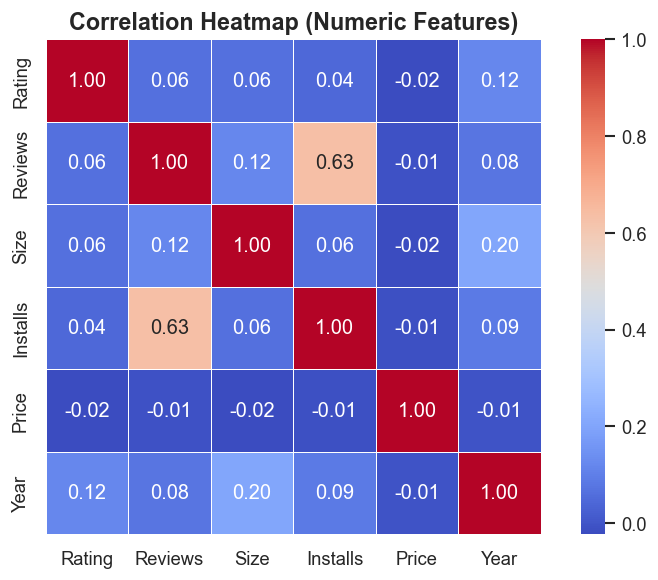

In [49]:
# Correlation Heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(correlationPlaystore, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, square=True)
plt.title('Correlation Heatmap (Numeric Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 2. Top Category of Apps

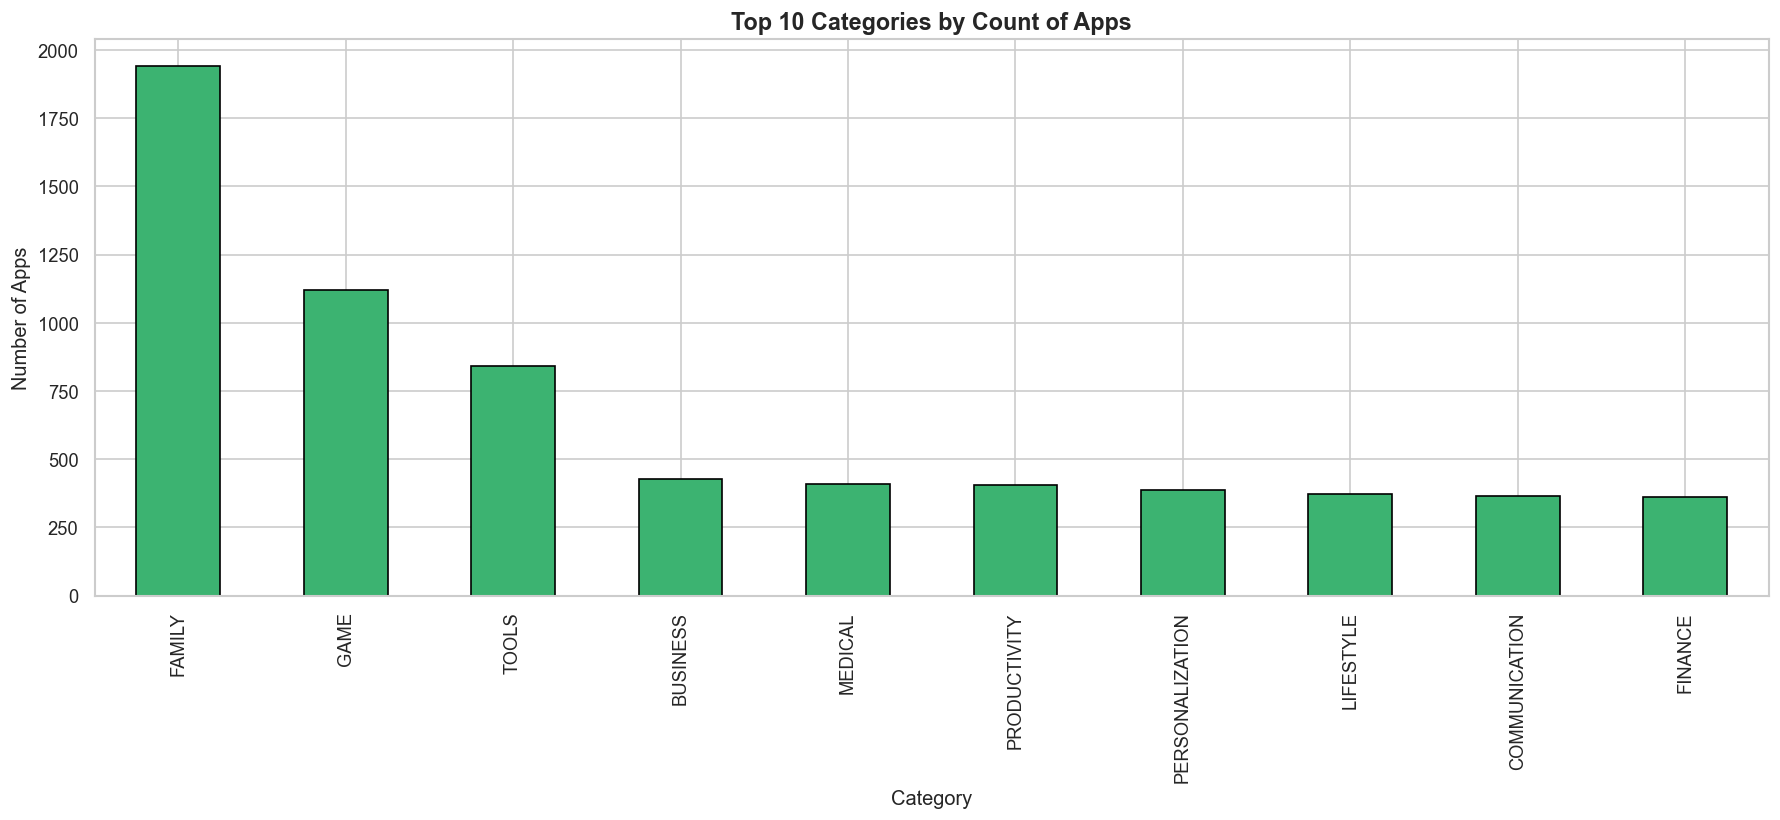

In [50]:
# Top 10 Category Apps by count
plt.figure(figsize=(15, 7))

CategoryCount.head(10).plot(kind="bar", color='mediumseagreen', edgecolor='black')
plt.title('Top 10 Categories by Count of Apps', fontsize=14, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Number of Apps', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### 3. Free VS Paid

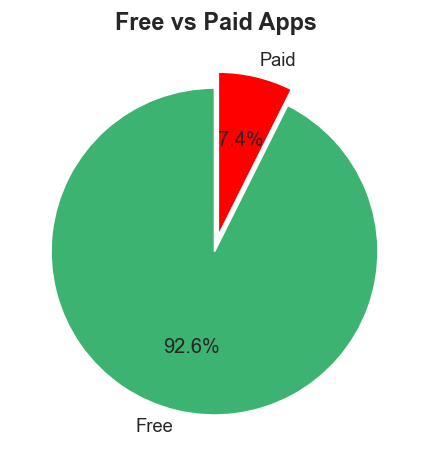

In [51]:
# Free vs Paid apps

plt.figure(figsize=(4, 4))
TypeCount.plot(
    kind='pie',
    autopct="%1.1f%%",
    colors=['mediumseagreen', 'red'],
    startangle=90,
    explode=(0.05, 0.05),
    labels=['Free', 'Paid']
)

plt.title('Free vs Paid Apps', fontsize=14, fontweight='bold')
plt.ylabel('')
plt.tight_layout()
plt.show()

### 4. Categorywise Install

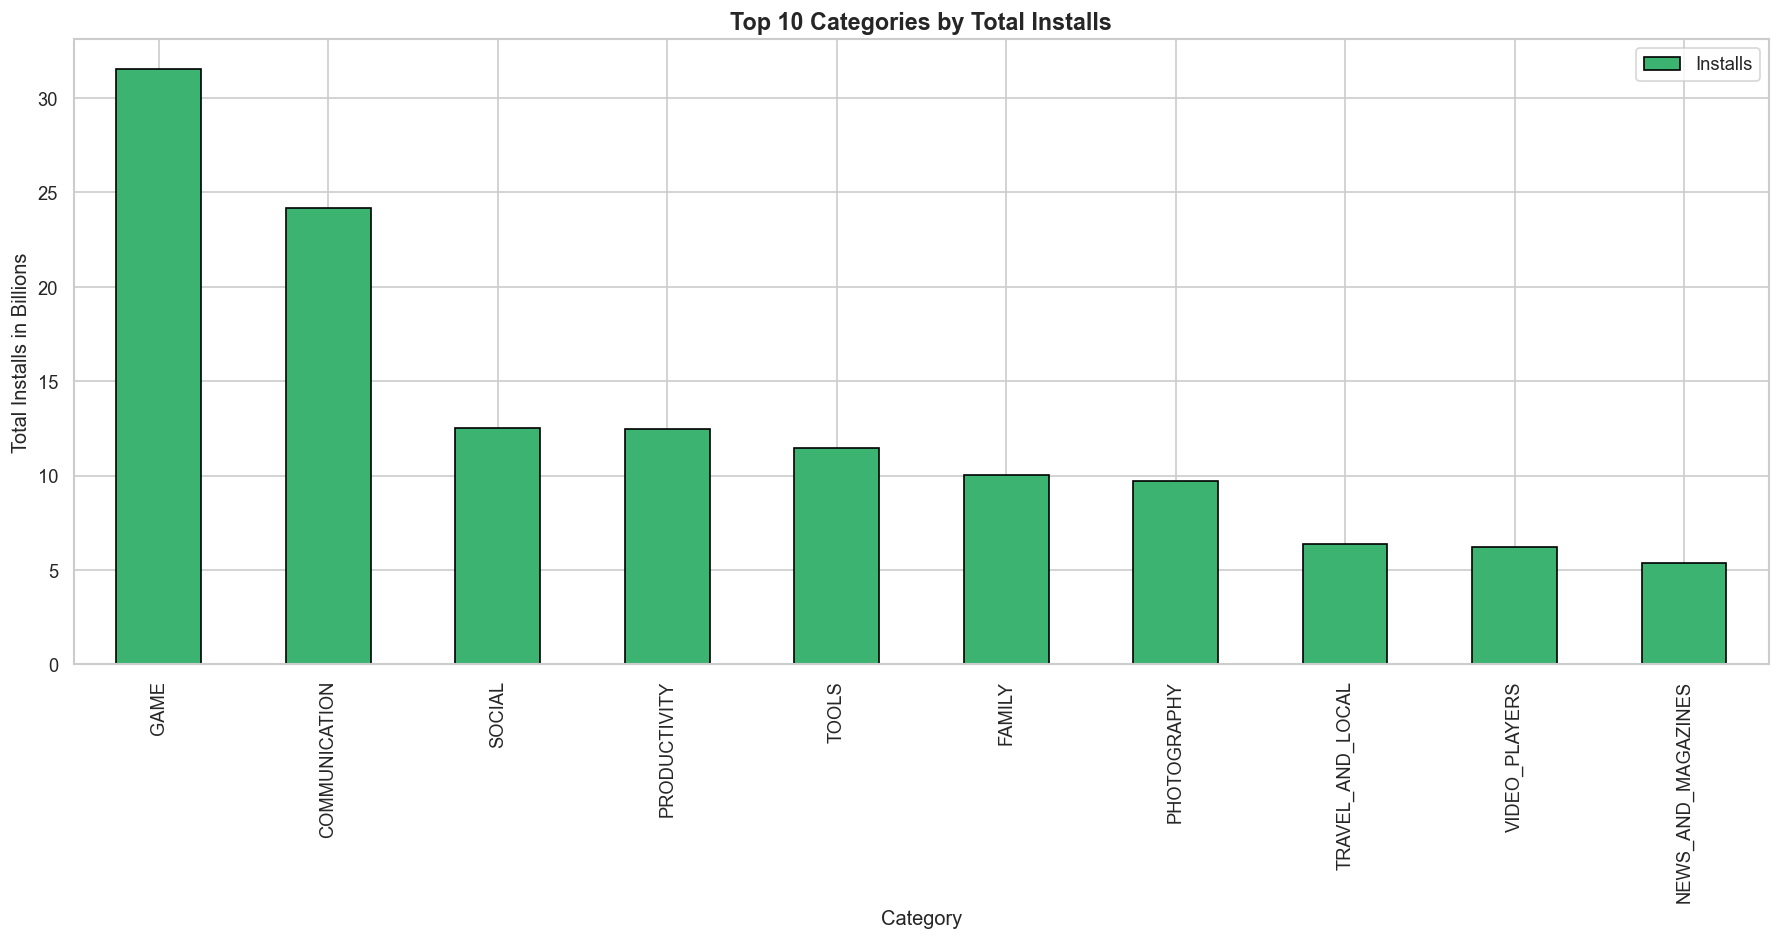

In [52]:
# Top 10 Categories by install

plt.figure(figsize=(15,8))

CategoryInstalls.head(10).plot(kind='bar', x='Category', y='Installs', color='mediumseagreen', edgecolor='black', ax=plt.gca())
plt.title('Top 10 Categories by Total Installs', fontsize=14, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Installs in Billions', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### 5. Distribution of App Ratings

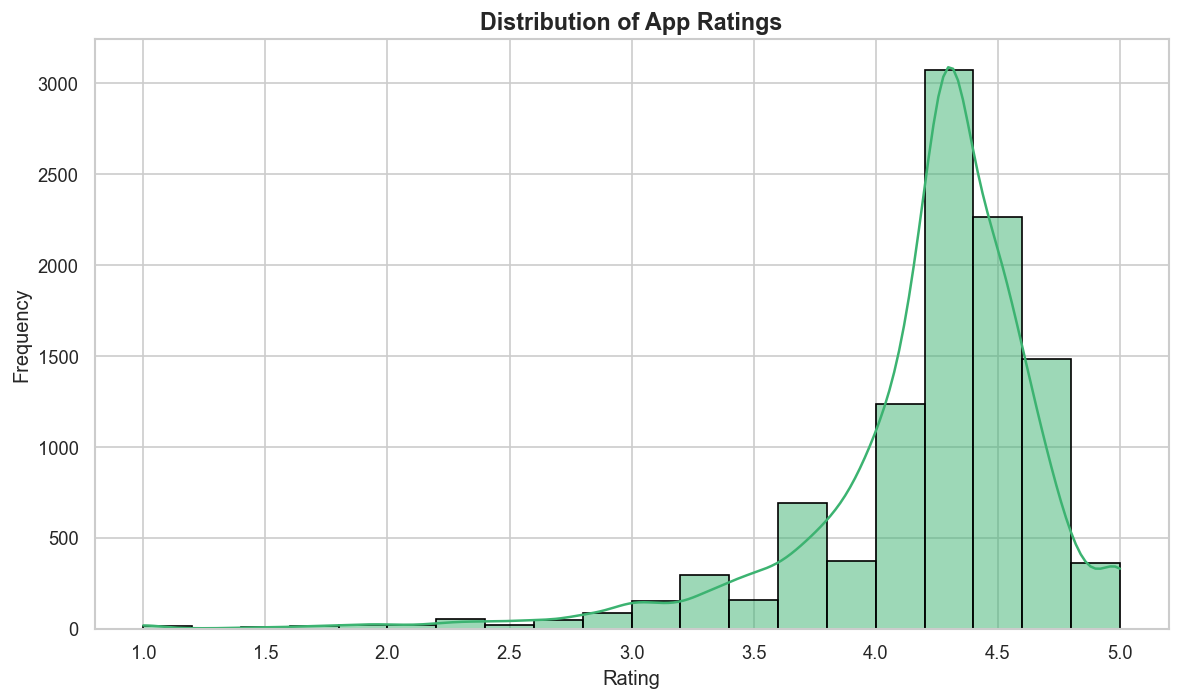

In [53]:
# Distribution of App Ratings
plt.figure(figsize=(10, 6))

sns.histplot(playstore['Rating'], bins=20, kde=True, color ="mediumseagreen", edgecolor="black")

plt.title("Distribution of App Ratings", fontsize=14, fontweight="bold")
plt.xlabel("Rating", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.tight_layout()
plt.show()

### 6. Free vs Paid Rating

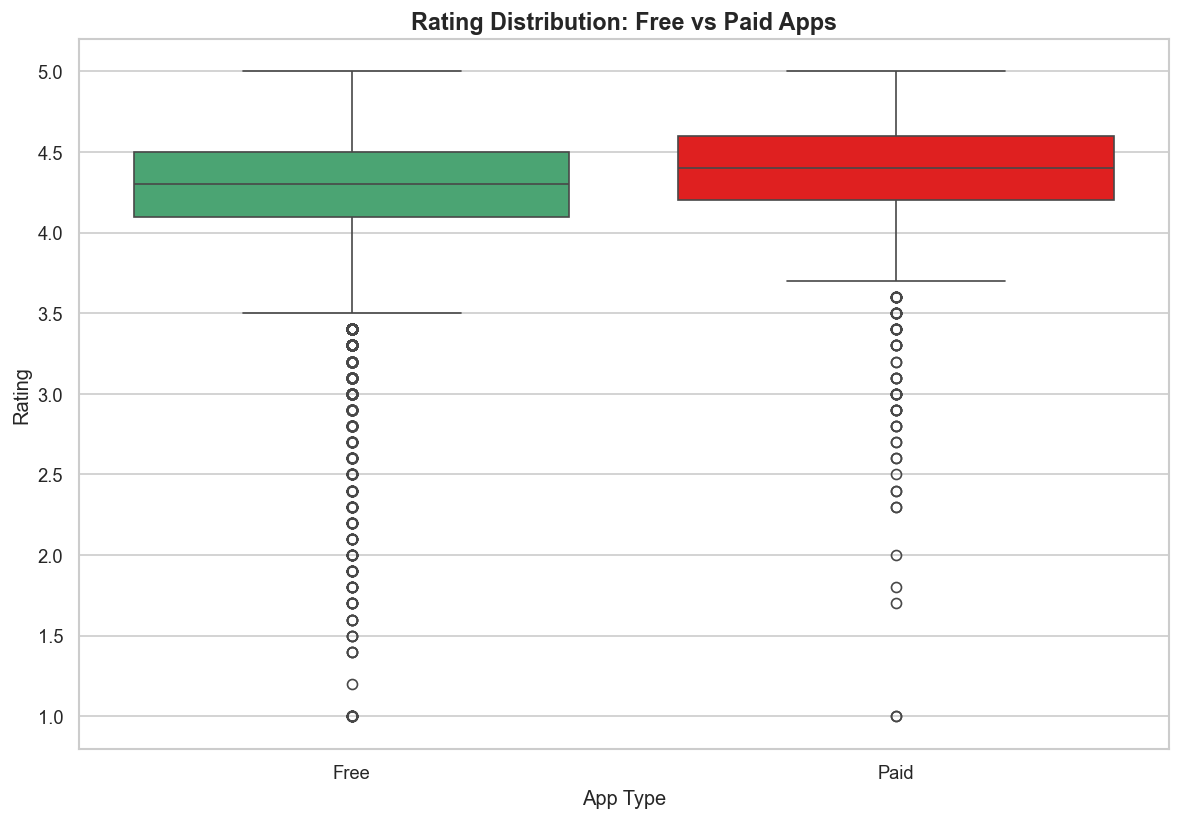

In [54]:
# Free vs Paid Rating

plt.figure(figsize=(10, 7))

sns.boxplot(
    data = playstore,
    x="Type",
    y="Rating",
    palette=["mediumseagreen", "red"]
)

plt.title('Rating Distribution: Free vs Paid Apps', fontsize=14, fontweight='bold')
plt.xlabel('App Type', fontsize=12)
plt.ylabel('Rating', fontsize=12)
plt.tight_layout()
plt.show()

plt.show()

### 7. Top 10 Categories by AvgSize

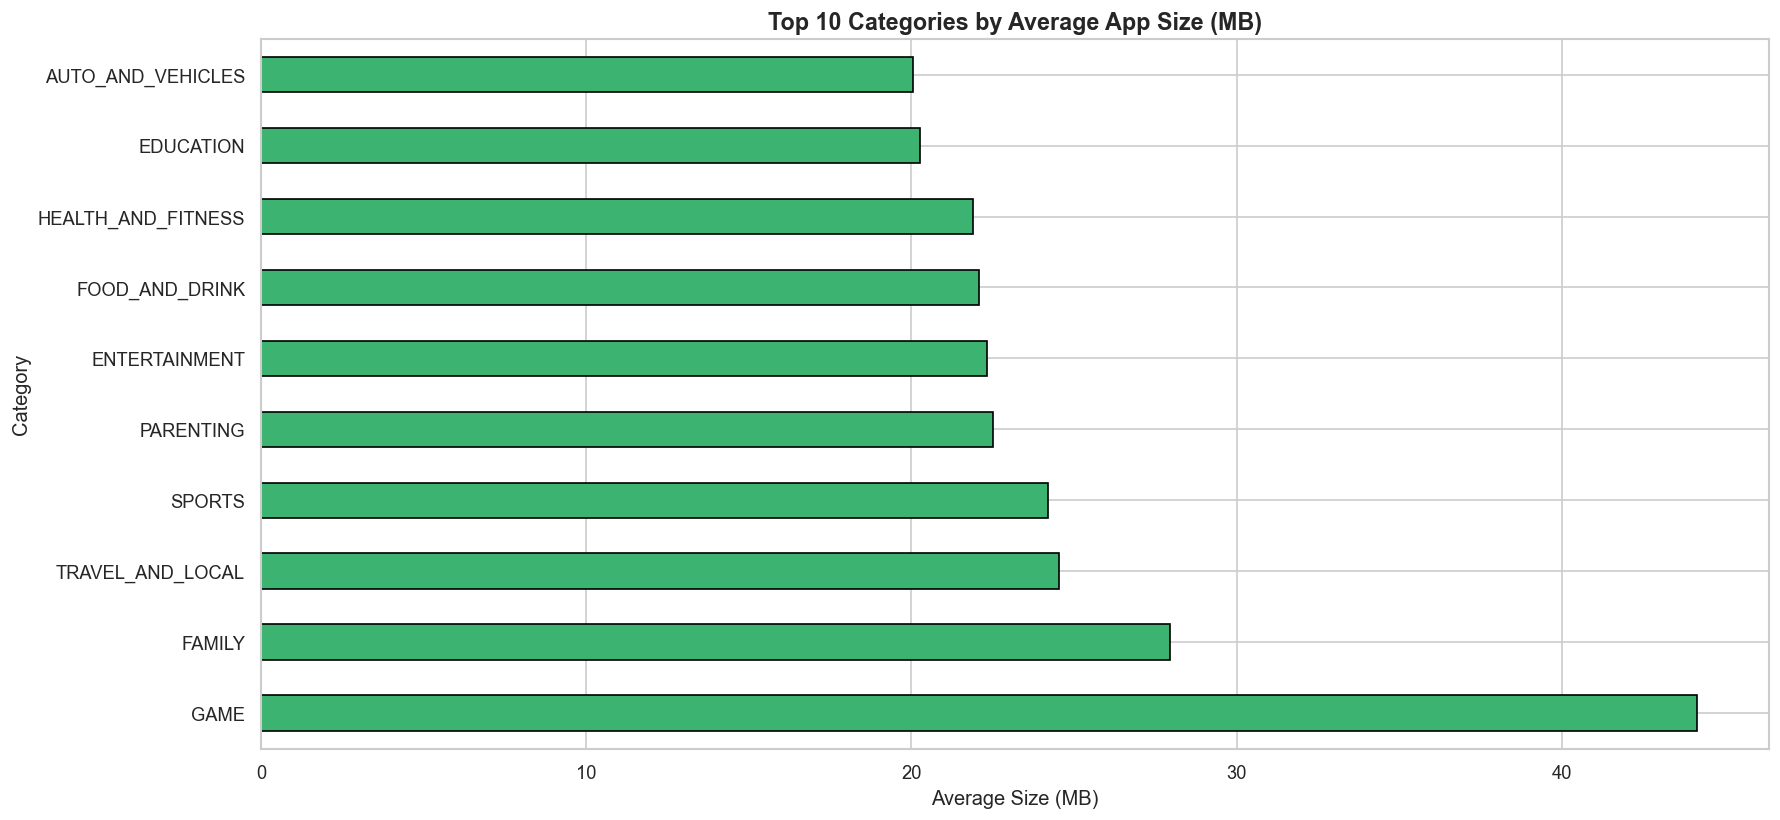

In [55]:
# Top 10 Categories by AvgSize

plt.figure(figsize=(15, 7))

CategorySize.head(10).plot(
    kind="barh",
    color="mediumseagreen",
    edgecolor="black"
)
plt.title('Top 10 Categories by Average App Size (MB)', fontsize=14, fontweight='bold')
plt.xlabel('Average Size (MB)', fontsize=12)
plt.ylabel('Category', fontsize=12)

plt.tight_layout()
plt.show()

### 8. Sentiment Distribution

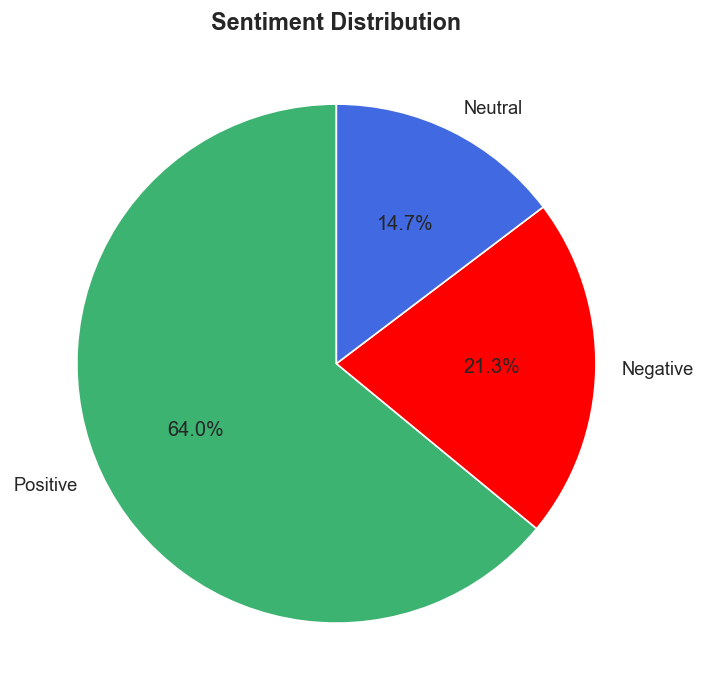

In [56]:
# Sentiment Distribution

plt.figure(figsize=(8, 6))

SentimentCounts.plot(
    kind='pie',
    autopct="%1.1f%%",
    colors=['mediumseagreen', 'red', 'royalblue'],
    startangle=90,
    labels=['Positive', 'Negative', 'Neutral']
)
plt.title('Sentiment Distribution', fontsize=14, fontweight='bold')
plt.ylabel('')
plt.tight_layout()
plt.show()

### 9. Reviews per Year

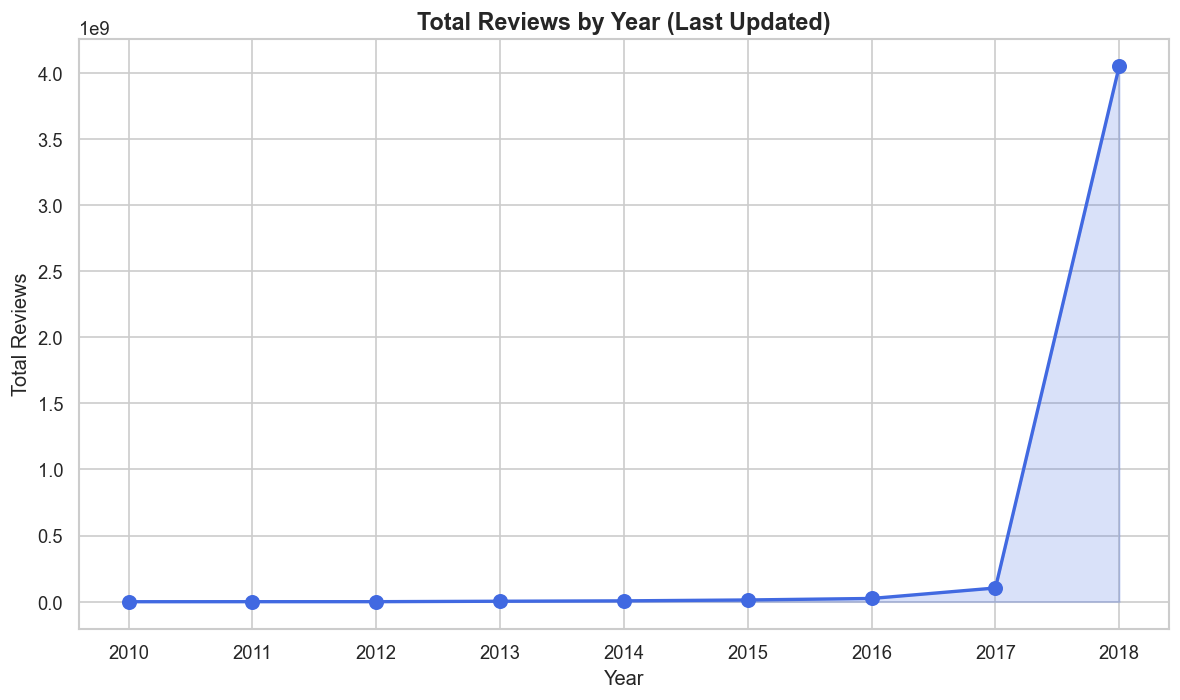

In [57]:
# Total Review by Year
plt.figure(figsize=(10, 6))

plt.plot(
    ReviewYear.index,
    ReviewYear.values,
    marker="o",
    linewidth=2,
    color='royalblue',
    markersize=8
)
plt.fill_between(
    ReviewYear.index,
    ReviewYear.values,
    color='royalblue',
    alpha=0.2
)
plt.title('Total Reviews by Year (Last Updated)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Reviews', fontsize=12)
plt.tight_layout()
plt.show()

### 10. Top 10 Positive Sentiment per Category

<Figure size 1800x840 with 0 Axes>

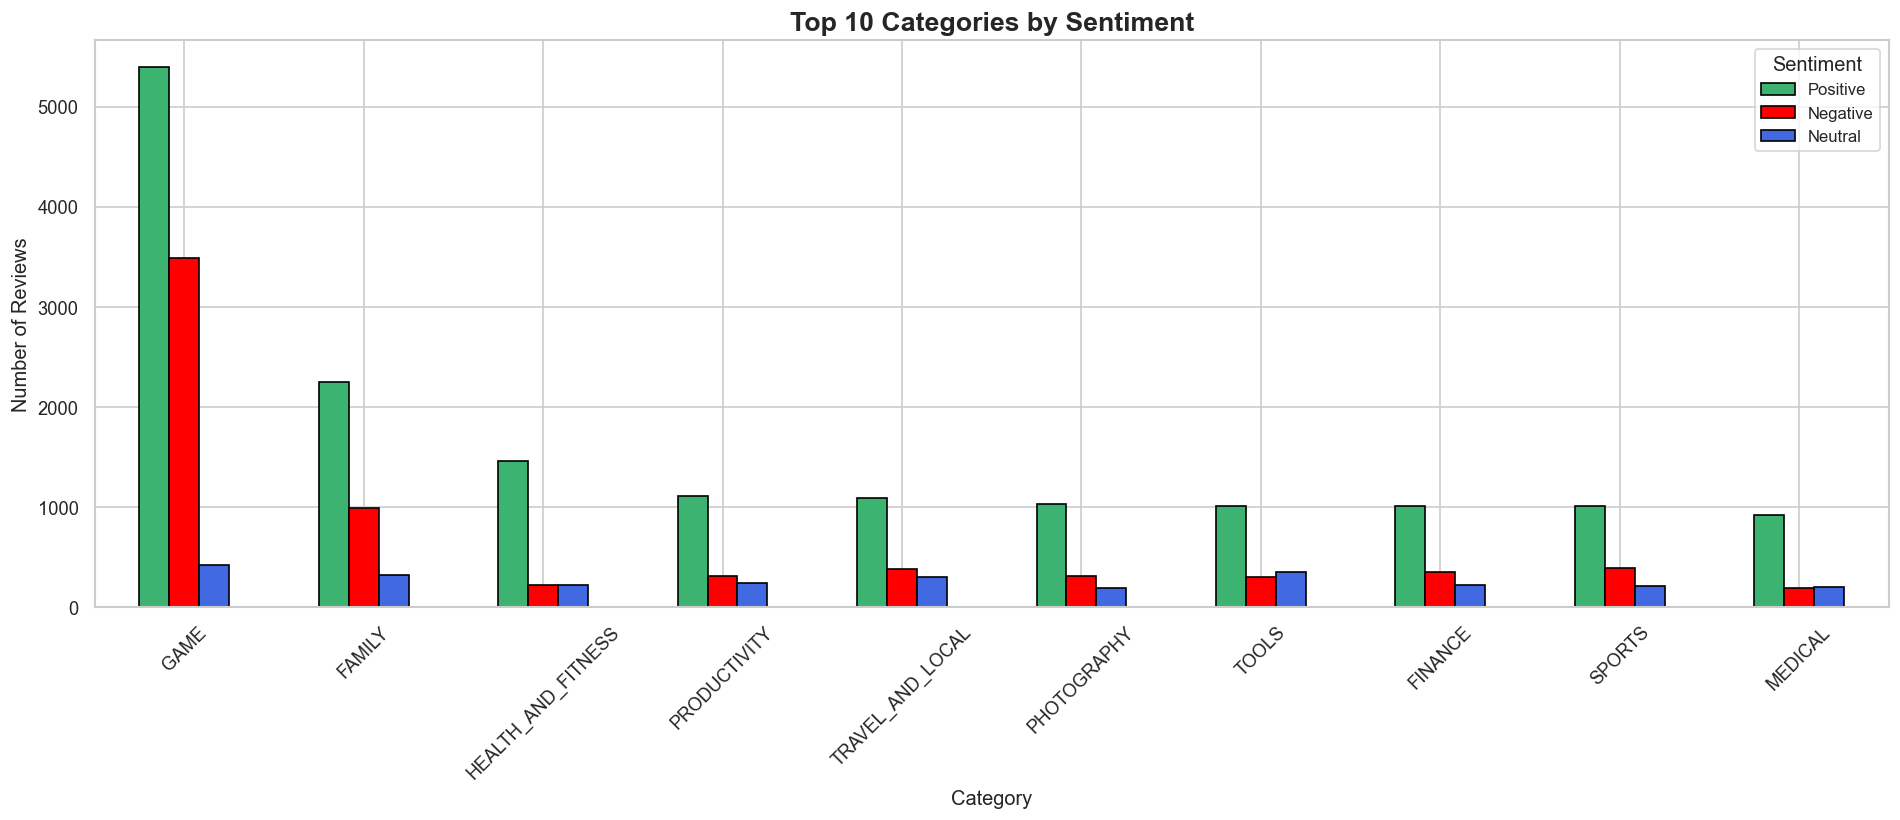

In [58]:
# Top 10 Positive Sentiment per Category

plt.figure(figsize=(15, 7))

CategoryWiseSentiment.head(10).plot(
    kind='bar',
    figsize=(16, 7),
    color=['mediumseagreen', 'red', 'royalblue'],
    edgecolor='black'
)

plt.title('Top 10 Categories by Sentiment', fontsize=16, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Sentiment', fontsize=10)
plt.tight_layout()
plt.show()

## **Phase 5 :** Insights

### **1. Based on Visualization**

#### a. Correlation Analysis

- Strong +ve relation between Reviews and Install (More Installs = More Engagement)
- Rating don't dervive popularity strongly
- Size has negligible correlation with installs/reviews
- Price has -ve relation with installs (Price has nothing to do with installs)

#### b. Category Insights

- There is large no. of `Family`, `Games` and `Tools` category application are available at playstore.
- Highest installs come from **Games** and **Communication**
- Some categories have high app count but lower installs

#### c. Free vs Paid Apps

- **~92.6%** apps are Free, only **~7.4%** Paid.
- Free apps dominate both market share and installs.
- Paid apps have *Lower installs* but *Slightly higher median ratings*

#### d. Rating Distribution

- Most apps lie between 4.0 - 4.5 rating range
- Ratings are not a differentiating factor for installs.

#### e. App Size Insights

- Games have highest average size (~40+ MB)
- Utility apps (Education, Auto & Vehicles, etc.) are smaller
- Size does not impact installs or reviews significantly.

#### f. Sentiment Analysis

- **64% Positive**, ~21% Negative, ~15% Neutral.
- Positive sentiment has higher percentage that shows most applications are satisfying.
- Categories like Game & Family generate highest positive reviews.

### **2. Conclusion**

- The success of apps on the Google Play Store is driven by user engagement and category demand rather than technical factors like app size, price, or ratings.

- Free apps dominate the and achieve significantly higher installs compared to paid apps. Categories such as Games and Communication lead in total installs, indicating strong user demand.

- A strong relationship exists between installs and reviews, confirms that popular apps naturally attract more user feedback. Meanwhile, ratings, size, and price show a few influence on app success.

- Sentiment analysis further reveals that most users have a positive experience, successful apps focus on usability and engagement rather than just technical specifications.

## **Final Summary**

- In this project I performed a complete Exploratory Data Analysis (EDA) on Google Play Store data with user reviews.

- Key steps included:
  - Data cleaning (duplicates, missing values)
  - Feature transformation (price in INR, size normalization)
  - Data merging (playstore + user reviews)
  - Visualization-based analysis

- Using multiple visualization techniques such as heatmaps, bar charts, scatter plots, histograms, box plots, and pie charts, meaningful insights were extracted.

- From analysis we get to know that:
  - Installs and reviews are strongly related
  - Free apps dominate the market
  - Category selection plays a crucial role

- Overall, the study shows that app success depends more on accessibility, engagement, and market demand rather than technical attributes.